In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df = pd.read_csv(r"E:\Projects\Tasks\Complet project\Coffe_sales.csv")
df.head(3)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,3/1/2024,15:50.5
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,3/1/2024,19:22.5
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,3/1/2024,20:18.1


data check

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [71]:
df['Date'] = pd.to_datetime(df['Date'] , format='%m/%d/%Y')


In [72]:
df.duplicated().sum()

np.int64(0)

اكتر 3 منتجات اتباعت عندي 

In [73]:
x = df['coffee_name'].value_counts().head(3)
x

coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Name: count, dtype: int64

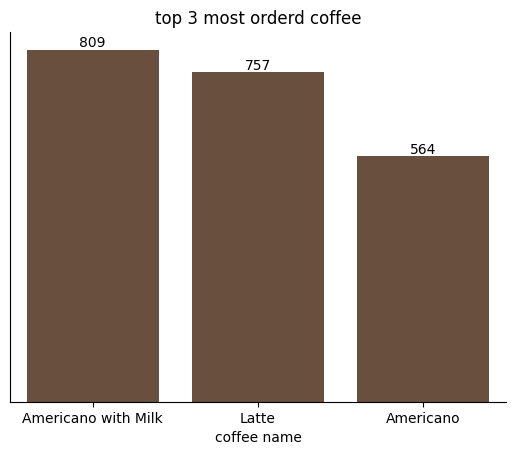

In [74]:
ax = sns.barplot(x=x.index , y=x.values , color="#6f4e37")
ax.bar_label(ax.containers[0])
plt.xlabel('coffee name')
plt.title('top 3 most orderd coffee')
plt.yticks([])
axis = plt.gca()
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)

اقل 3 منتجات اتباعوا عندي

In [75]:
x = df['coffee_name'].value_counts().tail(3)
x

coffee_name
Hot Chocolate    276
Cocoa            239
Espresso         129
Name: count, dtype: int64

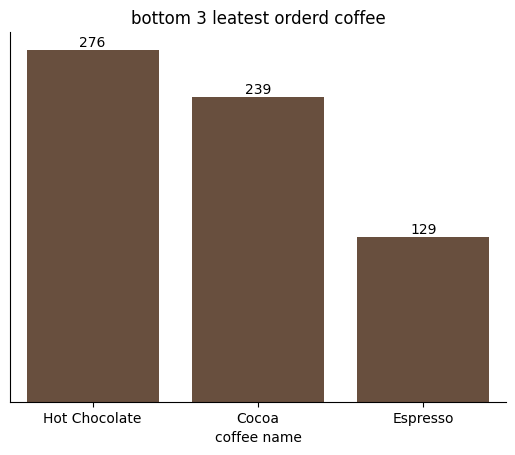

In [76]:
ax = sns.barplot(x=x.index , y=x.values , color="#6f4e37")
ax.bar_label(ax.containers[0])
plt.xlabel('coffee name')
plt.title('bottom 3 leatest orderd coffee')
plt.yticks([])
axis = plt.gca()
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)

كل مشروب دخلي قد اي

In [77]:
x = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)
x

coffee_name
Latte                  26875.30
Americano with Milk    24751.12
Cappuccino             17439.14
Americano              14650.26
Hot Chocolate           9933.46
Cocoa                   8521.16
Cortado                 7384.86
Espresso                2690.28
Name: money, dtype: float64

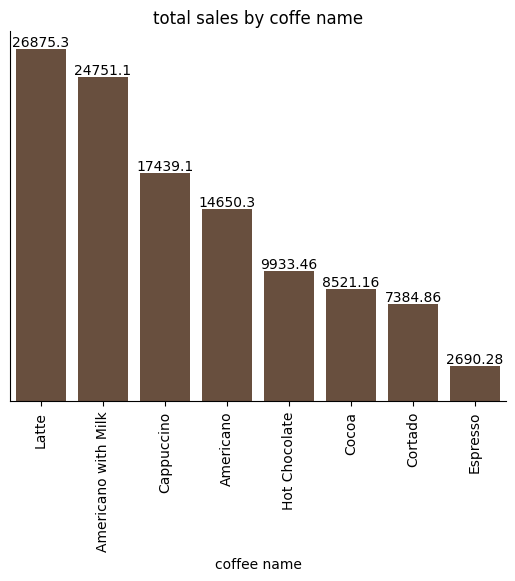

In [78]:
ax = sns.barplot(x=x.index , y=x.values , color="#6f4e37")
ax.bar_label(ax.containers[0])
plt.xlabel('coffee name')
plt.title('total sales by coffe name')
plt.yticks([])
plt.xticks(rotation=90)
axis = plt.gca()
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)

ﻫﻞ ﻓﻴﻪ ﻓﺮﻕ ﺑﻴﻦ "ﺍﻷﻛﺘﺮ ﻃﻠﺒﺎ" ﻭ"ﺍﻷﻛﺘﺮ ﺭﺑﺤﺎ"؟

In [79]:
summary = pd.DataFrame(
    {
        'order' : df['coffee_name'].value_counts().sort_index() ,
        'revenue' : df.groupby('coffee_name')['money'].sum().sort_index()
    }
)

summary

,order,revenue
coffee_name,,
Americano,564,14650.26
Americano with Milk,809,24751.12
Cappuccino,486,17439.14
Cocoa,239,8521.16
Cortado,287,7384.86
Espresso,129,2690.28
Hot Chocolate,276,9933.46
Latte,757,26875.30


توﺯﻳﻊ ﺳﻌﺮ ﻛﻞ ﻣﺸﺮﻭﺏ

In [80]:
df.groupby('coffee_name')['money'].agg(['mean','sum','max','min'])

,mean,sum,max,min
coffee_name,,,,
Americano,25.975638,14650.26,28.9,23.02
Americano with Milk,30.594710,24751.12,33.8,27.92
Cappuccino,35.883004,17439.14,38.7,32.82
Cocoa,35.653389,8521.16,38.7,32.82
Cortado,25.731220,7384.86,28.9,23.02
Espresso,20.854884,2690.28,24.0,18.12
Hot Chocolate,35.990797,9933.46,38.7,32.82
Latte,35.502378,26875.30,38.7,32.82


ﺇﻳﻪ ﺃﻛﺘﺮ ﺳﺎﻋﺎﺕ ﺍﻟﻴﻮﻡ انا ببيع فيها

In [81]:
df.head(3)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,15:50.5
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,19:22.5
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,20:18.1


In [82]:
x = df.groupby('hour_of_day' , as_index=False)['money'].sum().sort_values('money' ,ascending=False)
x

,hour_of_day,money
4,10,10198.52
10,16,9031.84
5,11,8453.10
13,19,7751.96
11,17,7659.76
9,15,7476.02
6,12,7419.62
3,9,7264.28
8,14,7173.80
12,18,7162.60


Text(0.5, 1.0, 'total sales by hours of day')

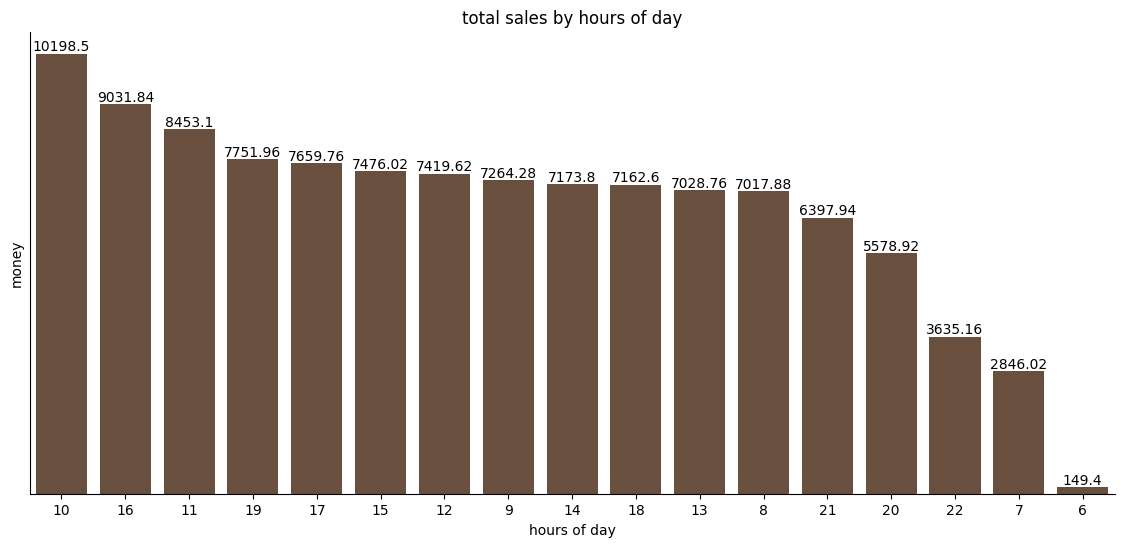

In [83]:
plt.figure(figsize=(14,6))
ax = sns.barplot(x='hour_of_day' , y='money' , data=x , order=x['hour_of_day'],color="#6f4e37")
ax.bar_label(ax.containers[0])
plt.xlabel('hours of day')
plt.yticks([])
axis = plt.gca()
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
plt.title('total sales by hours of day')

هل المبيعات بتفرق من حيث الكميه في اوقات اليوم

In [84]:
df

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.70,Latte,Morning,Fri,Mar,5,3,2024-03-01,15:50.5
1,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,19:22.5
2,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,20:18.1
3,13,card,28.90,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,46:33.0
4,13,card,38.70,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,48:14.6
...,...,...,...,...,...,...,...,...,...,...,...
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,34:54.9
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,43:37.4
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,44:16.9
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,47:28.7


In [85]:
summary = df.groupby('Time_of_Day')['coffee_name'].value_counts().reset_index()
summary


,Time_of_Day,coffee_name,count
0,Afternoon,Latte,270
1,Afternoon,Americano with Milk,239
2,Afternoon,Americano,233
3,Afternoon,Cappuccino,164
4,Afternoon,Cortado,88
5,Afternoon,Hot Chocolate,80
6,Afternoon,Cocoa,75
7,Afternoon,Espresso,56
8,Morning,Americano with Milk,331
9,Morning,Americano,219


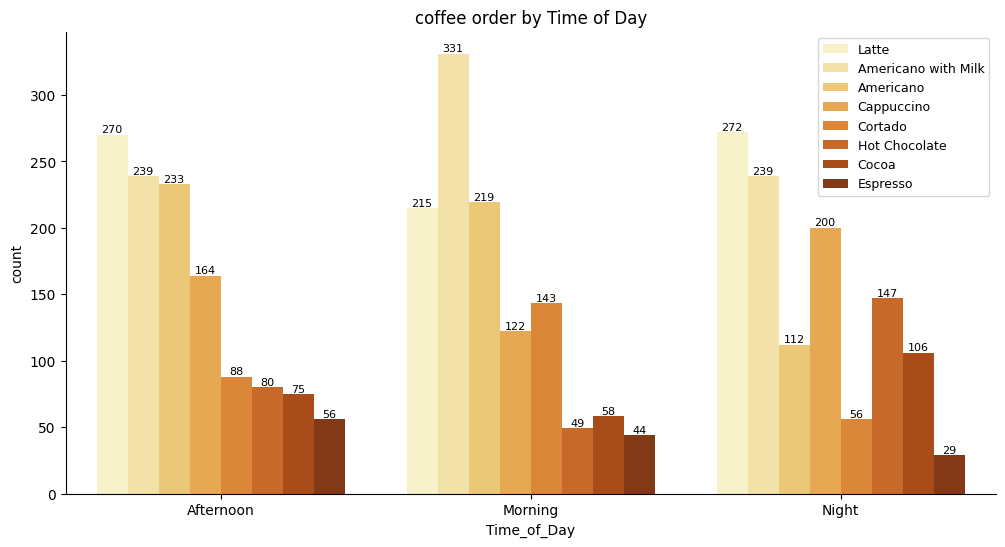

In [86]:
plt.figure(figsize=(12,6))
ax = sns.barplot(
    x='Time_of_Day', y='count' , data=summary ,hue='coffee_name' , palette='YlOrBr'
)

plt.legend(fontsize=9)

for container in ax.containers:
    ax.bar_label(container , fontsize=8)

plt.title('coffee order by Time of Day')

axis = plt.gca()
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)

In [87]:
df.head(3)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,15:50.5
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,19:22.5
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,20:18.1


 إيه أكتر أيام الأسبوع مبيعا؟

In [88]:
x = df.groupby('Weekday')['money'].sum().sort_values(ascending=False)
x

Weekday
Tue    18168.38
Mon    17363.10
Fri    16802.66
Thu    16091.40
Wed    15750.46
Sat    14733.52
Sun    13336.06
Name: money, dtype: float64

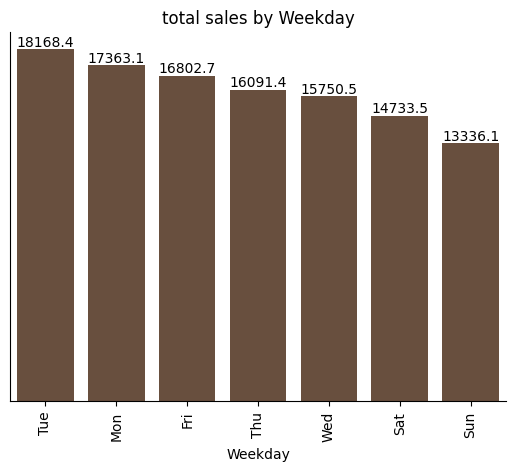

In [89]:
ax = sns.barplot(x=x.index , y=x.values , color="#6f4e37")
ax.bar_label(ax.containers[0])
plt.xlabel('Weekday')
plt.title('total sales by Weekday')
plt.yticks([])
plt.xticks(rotation=90)
axis = plt.gca()
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)

هل في شهور بمبيعات أعلى من غيرها ؟

ممكن يكون له علاقة بالجو أو المناسبات؟

In [90]:
z = df.groupby('Month_name')['money'].sum().sort_values(ascending=False)

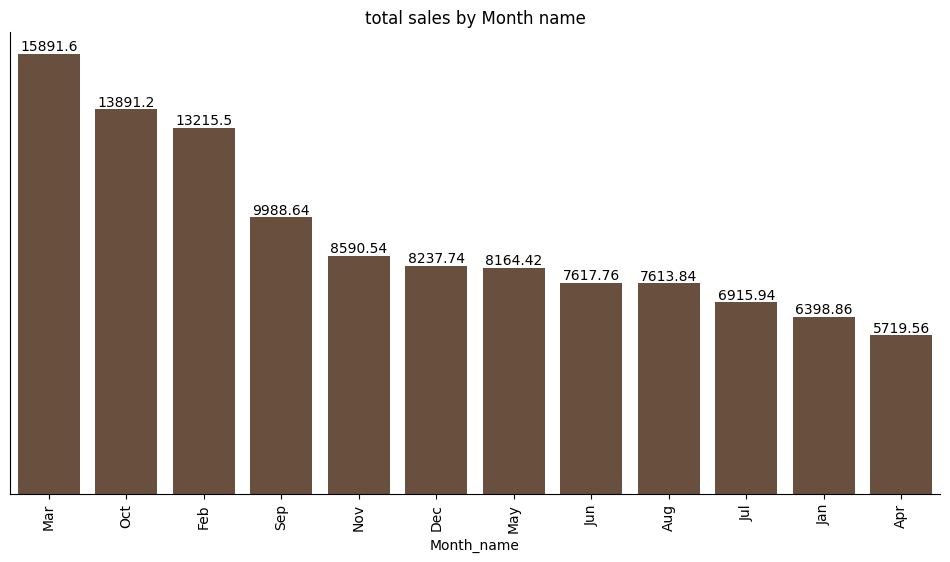

In [91]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x=z.index , y=z.values , color="#6f4e37")
ax.bar_label(ax.containers[0])
plt.xlabel('Month_name')
plt.title('total sales by Month name')
plt.yticks([])
plt.xticks(rotation=90)
axis = plt.gca()
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)

### الإيرادت

إجمالي الإيراد اليومي والشهري؟

In [92]:
df.head(1)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,15:50.5


In [93]:
x = df.groupby(['Month_name'])['money'].sum().sort_index().reset_index()
x

,Month_name,money
0,Apr,5719.56
1,Aug,7613.84
2,Dec,8237.74
3,Feb,13215.48
4,Jan,6398.86
5,Jul,6915.94
6,Jun,7617.76
7,Mar,15891.64
8,May,8164.42
9,Nov,8590.54


In [94]:
x = df.groupby(['Monthsort'])['money'].sum().sort_index().reset_index()
x

,Monthsort,money
0,1,6398.86
1,2,13215.48
2,3,15891.64
3,4,5719.56
4,5,8164.42
5,6,7617.76
6,7,6915.94
7,8,7613.84
8,9,9988.64
9,10,13891.16


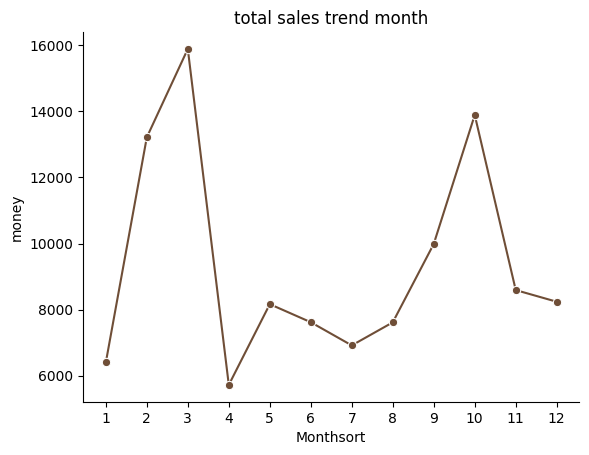

In [95]:
sns.lineplot(x='Monthsort',y= 'money',data=x,marker='o',color="#6f4e37")
x_axis = np.arange(1,13,1)
plt.xticks(x_axis)

plt.title('total sales trend month')
axis = plt.gca()
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
plt.show()

In [96]:
x=df.groupby(['Weekdaysort'])['money'].sum().sort_index().reset_index()
x

,Weekdaysort,money
0,1,17363.10
1,2,18168.38
2,3,15750.46
3,4,16091.40
4,5,16802.66
5,6,14733.52
6,7,13336.06


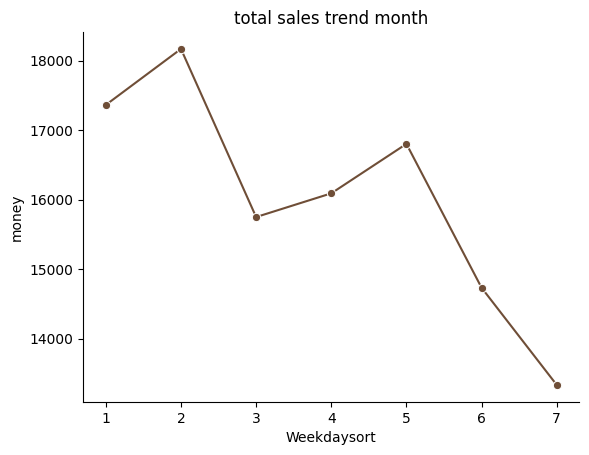

In [97]:
sns.lineplot(x='Weekdaysort',y= 'money',data=x,marker='o',color="#6f4e37")
x_axis = np.arange(1,8,1)
plt.xticks(x_axis)

plt.title('total sales trend month')
axis = plt.gca()
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
plt.show()

متوسط قيمة الفاتورة الواحدة ,و هل بيختلف حسب الوقت أو أو المشروب؟

In [98]:
df.head(1)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,15:50.5


In [99]:
x = df.groupby('Time_of_Day')['money'].mean().sort_values(ascending=False)
x

Time_of_Day
Night        32.890904
Afternoon    31.643187
Morning      30.422693
Name: money, dtype: float64

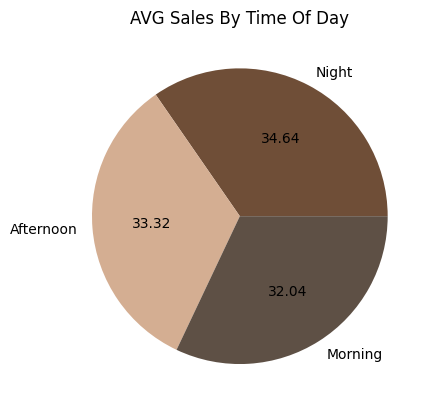

In [100]:
plt.pie(x,labels=x.index, autopct='%1.2f',colors=['#6f4e37' , "#d4ae92","#5e5045"])
plt.title('AVG Sales By Time Of Day')
plt.show()

In [101]:
x = df.groupby('coffee_name')['money'].mean().sort_values(ascending=False)
x

coffee_name
Hot Chocolate          35.990797
Cappuccino             35.883004
Cocoa                  35.653389
Latte                  35.502378
Americano with Milk    30.594710
Americano              25.975638
Cortado                25.731220
Espresso               20.854884
Name: money, dtype: float64

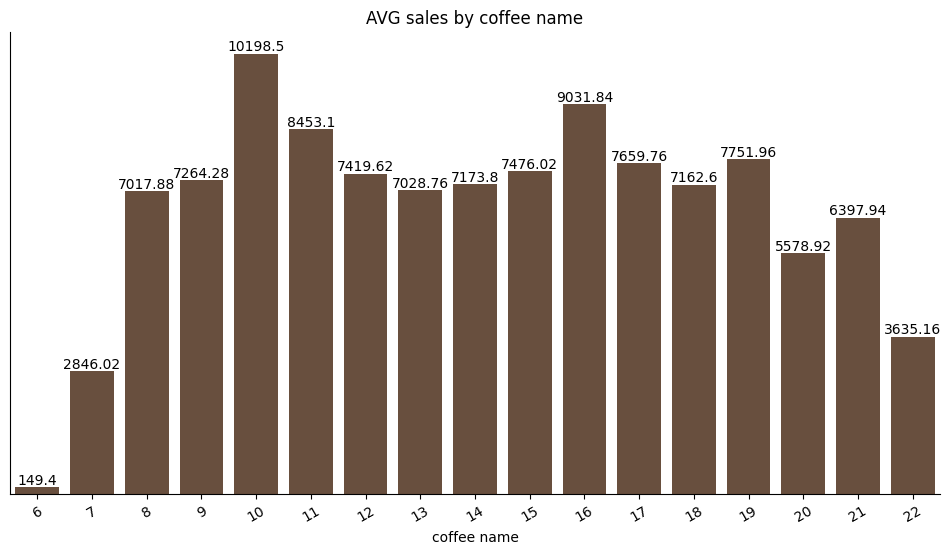

In [112]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x=x.index , y=x.values , color="#6f4e37")
ax.bar_label(ax.containers[0])
plt.xlabel('coffee name')
plt.title('AVG sales by coffee name')
plt.yticks([])
plt.xticks(rotation=30)

axis = plt.gca()
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)

هل فيه أيام أو ساعات معينة بإيراد أعلى بشكل ملحوظ يستاهل نركز عليها بعروض؟

In [103]:
x = df.groupby('Weekday')['money'].sum().sort_values(ascending=False)
x

Weekday
Tue    18168.38
Mon    17363.10
Fri    16802.66
Thu    16091.40
Wed    15750.46
Sat    14733.52
Sun    13336.06
Name: money, dtype: float64

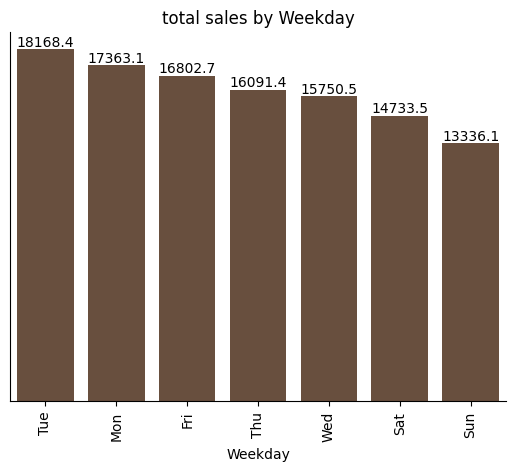

In [104]:
ax = sns.barplot(x=x.index , y=x.values , color="#6f4e37")
ax.bar_label(ax.containers[0])
plt.xlabel('Weekday')
plt.title('total sales by Weekday')
plt.yticks([])
plt.xticks(rotation=90)
axis = plt.gca()
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)

In [105]:
x = df.groupby('hour_of_day')['money'].sum().sort_values(ascending=False)
x

hour_of_day
10    10198.52
16     9031.84
11     8453.10
19     7751.96
17     7659.76
15     7476.02
12     7419.62
9      7264.28
14     7173.80
18     7162.60
13     7028.76
8      7017.88
21     6397.94
20     5578.92
22     3635.16
7      2846.02
6       149.40
Name: money, dtype: float64

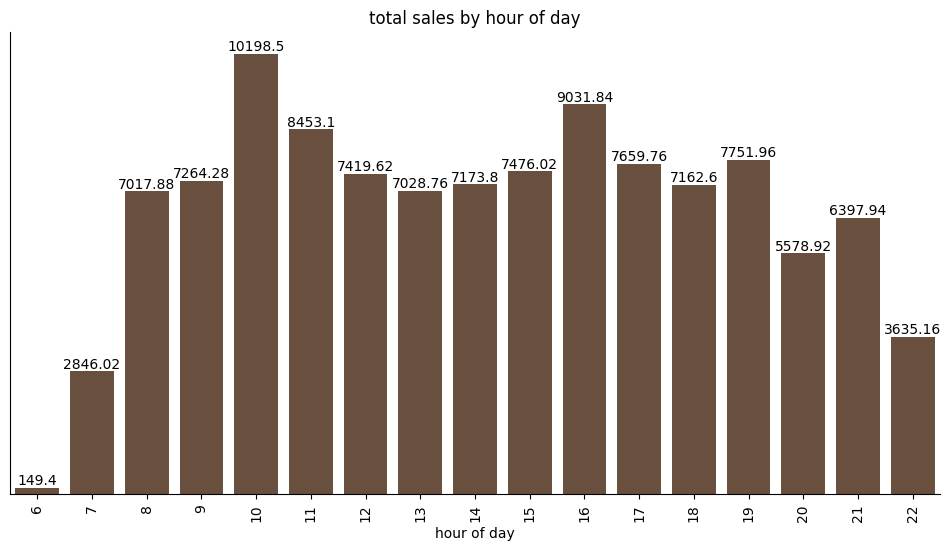

In [111]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x=x.index , y=x.values , color="#6f4e37")
ax.bar_label(ax.containers[0])
plt.xlabel('hour of day')
plt.title('total sales by hour of day')
plt.yticks([])
plt.xticks(rotation=90)

axis = plt.gca()
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)

### طريقة الدفع


إحصاء بسيط لعدد ونسبة كل طريقة دفع — حتى لو طلعت النتيجة إن كله دفع بالكارت، وضحولي ده كملاحظة مهمة في التقرير

In [113]:
x = df.groupby('cash_type')['money'].sum().sort_values(ascending=False)
x

cash_type
card    112245.58
Name: money, dtype: float64

In [115]:
print(df['money'].sum())

112245.57999999999


In [114]:
print(df['money'].mean())

31.64521567521849


In [116]:
print(df['coffee_name'].value_counts())

coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Cappuccino             486
Cortado                287
Hot Chocolate          276
Cocoa                  239
Espresso               129
Name: count, dtype: int64
